In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import subprocess
import itertools

import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator
from matplotlib.colors import LinearSegmentedColormap

from scipy import stats
from sklearn.cluster import *
from sklearn.decomposition import PCA
from sklearn.preprocessing import *
from sklearn.metrics import *

def set_font_size(ax, font_size):
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(font_size)

## Temporal analysis

## Contract statistics

- We consider the first 15 million blocks of the Ethereum blockchain (i.e., from height 0 to 14999999).
- We focus only on the ERC-721 Transfer events and take all smart contracts triggering at least one of these events.
- We count the number of Transfer events for each contract.

In [51]:
rank_nofilter = pd.read_csv('results/nft/ranking/nft_ranking_nofilter.csv', header=None, names=['contractId', 'numTransfer'])
rank_nofilter

,contractId,numTransfer
0,148,45
1,463,558
2,471,20239
3,496,1
4,833,188
...,...,...
83036,82258,4
83037,82647,2
83038,82701,1287
83039,82905,2


In [52]:
data = rank_nofilter.numTransfer.value_counts()
data = data.reindex(np.arange(1, np.max(data.index)+1), fill_value=0)
data

numTransfer
1           7081
2          11672
3           3900
4           5809
5           2214
           ...  
8000357        0
8000358        0
8000359        0
8000360        0
8000361        1
Name: count, Length: 8000361, dtype: int64

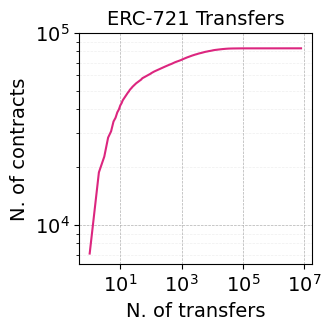

In [76]:
x = np.cumsum(data)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of contracts')
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(x.index, x.values, color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.set_ylim(top=1*1e5)
set_font_size(ax, 14)
plt.show()

/tmp/ipykernel_2035901/28630482.py:22: UserWarning: AutoMinorLocator does not work with logarithmic scale
  for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
/home/matteoL/.local/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


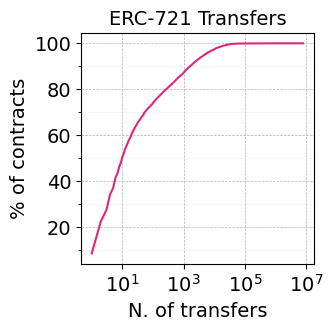

In [62]:
x = np.cumsum(data)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('% of contracts')
ax.set_xscale('log')
ax.plot(x.index, ((x.values * 100) / (x.values[-1])), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)
plt.show()

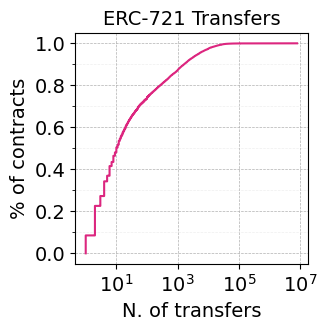

In [38]:
data = rank_nofilter.numTransfer
sorted_data = np.sort(data)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('% of contracts')
ax.set_xscale('log')
ax.step(sorted_data, np.arange(sorted_data.size)/sorted_data.size, color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)
plt.savefig("figures/nft_cumulative_transfers_contract.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [2]:
timestamps = pd.read_csv('data/block_timestamps_0-14999999.csv', names=['blockId','timestamp'])
block_stats = pd.read_csv('results/nft/nft_block_stats.csv', header=None, names=['blockId', 'numContract', 'numTransfer'])
block_stats = pd.DataFrame({'blockId':np.arange(0, 15000000)}).merge(block_stats, how='left', on=['blockId']).fillna(0).astype(int)
block_stats = block_stats.merge(timestamps, on=['blockId'], how='left')
block_stats['timestamp'] = block_stats['timestamp'].astype('datetime64[s]')
block_stats

,blockId,numContract,numTransfer,timestamp
0,0,0,0,2015-07-30 15:26:13
1,1,0,0,2015-07-30 15:26:28
2,2,0,0,2015-07-30 15:26:57
3,3,0,0,2015-07-30 15:27:28
4,4,0,0,2015-07-30 15:27:57
...,...,...,...,...
14999995,14999995,3,5,2022-06-21 02:27:32
14999996,14999996,26,66,2022-06-21 02:27:35
14999997,14999997,11,14,2022-06-21 02:27:51
14999998,14999998,3,22,2022-06-21 02:28:08


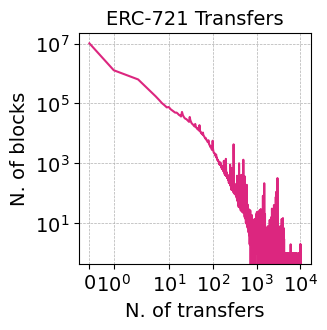

In [3]:
domain = np.arange(0, np.max(block_stats.numTransfer) + 1)
data = block_stats.numTransfer.value_counts().reindex(domain, fill_value=0)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of blocks')
ax.set_xscale('symlog')
ax.set_yscale('log')
ax.plot(data.index.values, data.values, color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)
plt.savefig("figures/nft_dist_transfers_block.pdf", format='pdf', bbox_inches='tight')
plt.show()

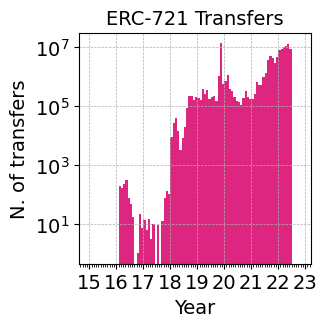

In [127]:
d1 = pd.to_datetime(block_stats.timestamp).astype(np.int64).values
d2 = block_stats.numTransfer.values
histBins = [pd.Timestamp(y, m, 1).timestamp() for y in range(2015, 2023, 1) for m in range(1, 12+1, 1)]
plotBins = [datetime.datetime(y, m, 1) for y in range(2015, 2023, 1) for m in range(1, 12+1, 1)]
s = stats.binned_statistic(d1, d2, statistic='sum', bins=histBins)

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot()
ax.set_title('ERC-721 Transfers')
ax.set_xlabel('Year')
ax.set_ylabel('N. of transfers')
ax.set_yscale('log')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator(12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.stairs(s.statistic[:-1], plotBins[:-1], color='#dc267f', fill=True)
ax.grid(linestyle='--', linewidth=0.5)
set_font_size(ax, 14)
plt.savefig("figures/nft_temporal_total_transfers.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [3]:
transfers = pd.read_csv('data/nft/erc721_transfers.csv', header=None, names=['blockId', 'contractId', 'fromId', 'toId'])
transfers

,blockId,contractId,fromId,toId
0,937821,0,1,1
1,937821,0,2,1
2,952792,0,1,3
3,952792,0,1,4
4,952899,0,1,5
...,...,...,...,...
107384858,14999999,2846,1682966,1360320
107384859,14999999,2846,2600890,1360320
107384860,14999999,2846,3265724,1360320
107384861,14999999,2846,2600890,2860429


In [9]:
tmp = block_stats[(block_stats.timestamp >= '2019-11-01') & (block_stats.timestamp < '2019-12-01')]
firstBlockId = np.min(tmp.blockId)
lastBlockId = np.max(tmp.blockId)
transfers_nov = transfers[(transfers.blockId >= firstBlockId) & (transfers.blockId <= lastBlockId)]
transfers_nov

,blockId,contractId,fromId,toId
4190977,8849472,225,0,59610
4190978,8849472,225,0,15128
4190979,8849472,225,0,15128
4190980,8849472,225,0,15128
4190981,8849472,225,0,15128
...,...,...,...,...
18041274,9029508,2147,297978,2434
18041275,9029508,2147,14909,297978
18041276,9029508,2147,297978,71040
18041277,9029508,2147,14909,297978


In [14]:
contracts = pd.read_csv('data/nft/erc721_contracts.csv', header=None, names=['contractAddress', 'contractId'])


,contractAddress,contractId
0,55b9a11c2e8351b4ffc7b11561148bfac9977855,0
1,86ca39d10dacdf1cfe490eb984bf0e7c17d1ed37,1
2,1802cdfd71a1fe4a4f342cd3fff8be6b468e091f,2
3,9a6140186f786e93057910638e3d1e248b577884,3
4,a6741d290898c2897177d439c7cda02e01c97ca3,4
...,...,...
83036,479b18c73eb4c4a36f1d473e1f42397e50755623,83036
83037,4c2503fd0fb7ad712a2c316a9b794434d25f7d0d,83037
83038,f4a0bc6f2026999ff6582c47771712bb2148d7c4,83038
83039,1e7a4a36d23cea2362b30e43d96780f5a198a244,83039


In [16]:
pd.DataFrame({'count':transfers_nov.groupby('contractId').size()})\
    .reset_index()\
    .sort_values(by=['count'], ascending=False)\
    .merge(contracts, how='left', on=['contractId']).head(5)

,contractId,count,contractAddress
0,2147,6962634,0e3a2a1f2146d86a604adc220b4967a898d7fe07
1,2038,6680552,629cdec6acc980ebeebea9e5003bcd44db9fc5ce
2,144,44698,8853b05833029e3cf8d3cbb592f9784fa43d2a79
3,784,27591,bd13e53255ef917da7557db1b7d2d5c38a2efe24
4,1038,25050,fac7bea255a6990f749363002136af6556b31e04


## Contract selection

We select the top 100 ERC-721 contracts based on the number of triggered Transfer events.<br>
We do not consider transfers directed to the null address (i.e., 0x0...0) or originating from this address.

In [38]:
rank_nofilter = pd.read_csv('results/nft/ranking/nft_ranking_nofilter.csv', header=None, names=['contractId', 'numTransfer'])
rank_filter = pd.read_csv('results/nft/ranking/nft_ranking_filter.csv', header=None, names=['contractId', 'numTransferFiltered'])
contractAddresses = pd.read_csv('data/nft/erc721_contracts.csv', header=None, names=['contractAddress', 'contractId'])
rank = rank_nofilter.merge(rank_filter, on=['contractId'], how='left').fillna(0).astype(int)
rank = rank.merge(contractAddresses, on=['contractId'], how='left')
rank = rank[['contractId', 'contractAddress', 'numTransfer', 'numTransferFiltered']]
rank['variationPerc'] = ((rank['numTransfer']-rank['numTransferFiltered']) * 100) / rank['numTransfer']
rank = rank.sort_values(by=['numTransferFiltered'], ascending=False).reset_index(drop=True)
rank

,contractId,contractAddress,numTransfer,numTransferFiltered,variationPerc
0,2846,57f1887a8bf19b14fc0df6fd9b2acc9af147ea85,3562588,1837127,48.432797
1,2147,0e3a2a1f2146d86a604adc220b4967a898d7fe07,8000361,1028936,87.138880
2,4368,629a673a8242c2ac4b7b8c5d8735fbeac21a6205,1145513,815331,28.823942
3,6668,a7d8d9ef8d8ce8992df33d8b8cf4aebabd5bd270,430461,254442,40.890812
4,7003,3b3ee1931dc30c1957379fac9aba94d1c48a5405,383833,234387,38.935162
...,...,...,...,...,...
83036,12864,42a5c85d1fbb489da4d26bfd4c5cbad558ee8818,11,0,100.000000
83037,13454,c9c48d3a6e53fd920b97980488fddeb54ade5ad0,3,0,100.000000
83038,13732,dd386b1c51b7ba70cad763b184de9c8844ccd263,1,0,100.000000
83039,14231,5abf8697b8a970d198f14dcb495c4ba3cf530c58,1,0,100.000000


## Graph construction

We import the TSV file summarizing the properties of all 100 token networks. For each network we recorded the following information:

1. Number of nodes.
2. Number of edges.
3. Number of weakly connected components.
4. Time elapsed for the construction of the graph.

In [2]:
df = pd.read_csv('results/nft/nft_analyze_full.tsv', sep='\t')
df

,contract_id,num_nodes,num_edges,num_wcc,elapsed_time
0,0,475162,559609,13,368974619
1,1,7069,23652,99,16796975
2,2,29838,302342,9,122703640
3,3,54983,172215,1131,91355913
4,4,48017,53346,33,36198876
...,...,...,...,...,...
95,95,19061,28435,223,18714913
96,96,17399,27067,167,18029106
97,97,10978,24447,7,20221986
98,98,13094,23592,21,17558033


We print the average number of nodes and edges among all 100 token networks.

In [4]:
print(f'Avg. nodes: {np.mean(df.num_nodes)}\nAvg. edges: {np.mean(df.num_edges)}')

Avg. nodes: 21283.06
Avg. edges: 36710.91


We then plot the cumulative distribution functions for the number of nodes and number of edges across all 100 graphs.

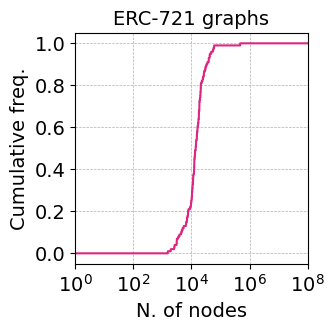

In [136]:
sizes = df.num_nodes.values
hist, bins = np.histogram(sizes, bins = np.arange(0, 1e8+1, 10))
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 graphs')
ax.set_xlabel('N. of nodes')
ax.set_ylabel('Cumulative freq.')
ax.set_xscale('log')
ax.plot(bins[:-1], np.cumsum(hist)/np.sum(hist), color='#dc267f')
ax.grid(linestyle='--', linewidth=0.5)
ax.set_xlim(1, 1e8)
set_font_size(ax, 14)
plt.savefig("figures/nft_cumulative_nodes.pdf", format='pdf', bbox_inches='tight')
plt.show()

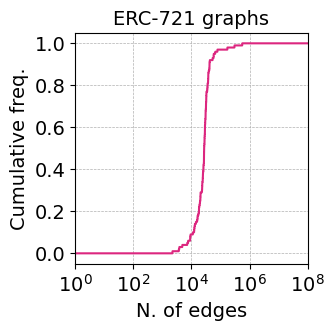

In [6]:
sizes = df.num_edges.values
hist, bins = np.histogram(sizes, bins = np.arange(0, 1e8+1, 10))
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 graphs')
ax.set_xlabel('N. of edges')
ax.set_ylabel('Cumulative freq.')
ax.set_xscale('log')
ax.plot(bins[:-1], np.cumsum(hist)/np.sum(hist), color='#dc267f')
ax.grid(linestyle='--', linewidth=0.5)
ax.set_xlim(1, 1e8)
set_font_size(ax, 14)
plt.savefig("figures/nft_cumulative_edges.pdf", format='pdf', bbox_inches='tight')
plt.show()

The following snippet creates a CSV file describing the connected components of each token network. The output file has one row for each graph. Each row has the following attributes:

1. Number of nodes in the whole graph.
2. Number of connected components of the graph.
3. Number of nodes in the largest connected component.
4. Percentage of nodes in the largest connected component (w.r.t. the total number of nodes).

In [13]:
full = pd.read_csv('results/nft/nft_analyze_full.tsv', sep='\t')
gcc = pd.read_csv('results/nft/nft_analyze_gcc.tsv', sep='\t')
res = gcc.merge(full, on='contract_id', how='left')[['contract_id', 'num_nodes', 'num_wcc', 'comp_nodes']]
res = res.rename(columns={'num_wcc':'num_cc', 'comp_nodes':'num_nodes_in_largest'})
res['ratio'] = res['num_nodes_in_largest'] / res['num_nodes']
res.to_csv('results/nft/nft_comp.csv', index=False)

## Graph analysis

Let $G$ be a token network and $G_{LCC}$ be the subgraph induced by the nodes and edges of its largest connected component.

We associate each $G$ with seven numerical features, namely:

1. Coverage, namely the percentage of nodes of $G$ included in $G_{LCC}$.
2. Alpha, which represents the exponent of the power law distribution best fitting the degree distribution of $G_{LCC}$.
3. Fitting error, which corresponds to the error obtained during the fitting process to obtain the previously described alpha.
4. Relative diameter, which represents the ratio between the diameter of $G_{LCC}$ and the natural logarithm of the number of nodes.
5. Relative average shortest path length, which is computed as the average shortest path length of $G_{LCC}$ divided by the natural logarithm of the number of nodes.
6. Transitivity coincides with the global clustering coefficient of $G_{LCC}$, namely the ratio between the number of triangles and connected triples in the graph.
7. Density, as the ratio between the actual number of edges and the maximum possible number of edges in $G_{LCC}$.

With the previously gathered information, we now create a CSV file containing these features for each of the 100 graphs. We also associate to each network a categorical label describing the application domain of the corresponding contract.

In [13]:
cat2int = {'pfps':0, 'gaming':1, 'art':2, 'virtual-worlds':3, 'domain-names':4, 'other':5}
comp = pd.read_csv('results/nft/nft_comp.csv')
fit_deg = pd.read_csv('results/nft/nft_fit_deg.tsv', sep='\t').rename(columns={'D':'error'})
path = pd.read_csv('results/nft/nft_path.tsv', sep='\t')
stats_gcc = pd.read_csv('results/nft/nft_analyze_gcc.tsv', sep='\t')
contract_info = pd.read_excel('results/nft/ranking/nft_top_labels.ods')
contract_info['category'] = contract_info['category'].fillna('other')
contract_info = contract_info[['contract_id', 'category', 'label', 'possible_spam']]
final = comp.merge(fit_deg, on='contract_id', how='left') \
    .merge(path, on='contract_id', how='left') \
    .merge(stats_gcc, on='contract_id', how='left') \
    .merge(contract_info, on='contract_id', how='left')
final['category_id'] = final['category'].map(cat2int)
final = final[['contract_id', 'label', 'possible_spam', 'category', 'category_id', 'comp_nodes', 'coverage', 'alpha', 'error', 'diameter', 'est_apl', 'transitivity', 'density']]
final['est_apl'] /= np.log(final['comp_nodes'])
final['diameter'] /= np.log(final['comp_nodes'])
final.to_csv('results/nft/nft_final.csv', index=False)

In [22]:
features = ['coverage', 'alpha', 'error', 'diameter', 'est_apl', 'transitivity', 'density'] # List of features used for clustering
final = pd.read_csv('results/nft/nft_final.csv')
final

,contract_id,label,possible_spam,category,category_id,comp_nodes,coverage,alpha,error,diameter,est_apl,transitivity,density
0,0,Ethereum Name Service,False,domain-names,4,475139,0.999952,2.455325,0.012106,11.934486,0.189888,0.000003,0.000005
1,1,Gods Unchained Cards,False,gaming,1,6841,0.967746,1.948671,0.024060,1.245656,0.354859,0.009671,0.001005
2,2,Sorare,False,gaming,1,29821,0.999430,2.074105,0.043536,0.970594,0.244640,0.010292,0.000680
3,3,Art Blocks,False,art,2,52451,0.953949,3.232256,0.028880,1.472261,0.411514,0.018652,0.000124
4,4,Foundation,False,art,2,47934,0.998271,3.090472,0.013191,2.783556,0.197647,0.000015,0.000046
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,The Heart Project,False,pfps,0,18458,0.968365,2.667838,0.012044,2.748580,0.638165,0.003304,0.000165
96,96,3Landers,False,pfps,0,16950,0.974194,2.848802,0.022792,2.156495,0.657548,0.003704,0.000186
97,97,Groupies,False,pfps,0,10963,0.998634,3.036929,0.024330,1.720008,0.481739,0.001951,0.000407
98,98,Pablos,False,pfps,0,13039,0.995800,2.631901,0.023805,1.582996,0.463189,0.002063,0.000277


In [3]:
final[final.contract_id == np.argmax(final.transitivity)]

,contract_id,label,possible_spam,category,category_id,comp_nodes,coverage,alpha,error,diameter,est_apl,transitivity,density
61,61,EtheremonMonster,False,gaming,1,2629,0.830648,2.658258,0.037498,2.412895,0.503314,0.091823,0.002528


In [23]:
final[final.contract_id == np.argmax(final.diameter)]

,contract_id,label,possible_spam,category,category_id,comp_nodes,coverage,alpha,error,diameter,est_apl,transitivity,density
35,35,Meebits,False,pfps,0,16691,0.953553,2.592374,0.017704,18.307813,0.86087,0.01007,0.000217


In [ ]:
final[final.contract_id == np.argmax(final.est_apl)]

,contract_id,label,possible_spam,category,category_id,comp_nodes,coverage,alpha,error,diameter,est_apl,transitivity,density
35,35,Meebits,False,pfps,0,16691,0.953553,2.592374,0.017704,18.307813,0.86087,0.01007,0.000217


In [4]:
final[features].mean().round(6)

coverage        0.960726
alpha           3.448814
error           0.021120
diameter        2.494966
est_apl         0.454593
transitivity    0.006362
density         0.000473
dtype: float64

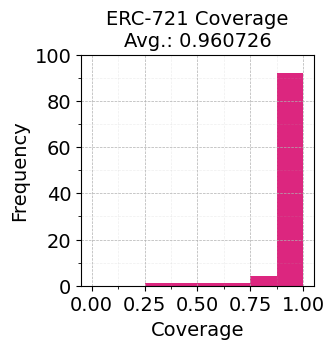

In [3]:
data = final['coverage']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Coverage\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Coverage')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0.0, 1.0+0.125, step=0.125), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 100)
set_font_size(ax, 14)
plt.savefig("figures/nft_feature_coverage_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

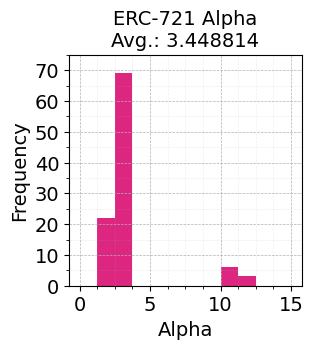

In [4]:
data = final['alpha']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Alpha\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Alpha')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0.0, 15.0+1.25, step=1.25), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 75)
set_font_size(ax, 14)
plt.savefig("figures/nft_feature_alpha_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

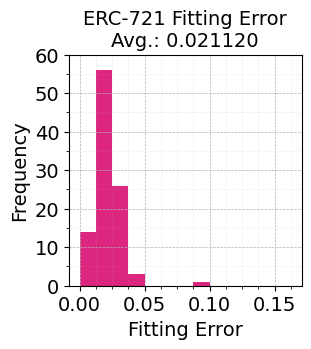

In [5]:
data = final['error']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Fitting Error\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Fitting Error')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0.0, 0.155+0.0125, step=0.0125), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 60)
set_font_size(ax, 14)
plt.savefig("figures/nft_feature_error_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

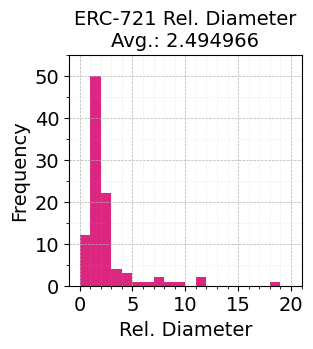

In [6]:
data = final['diameter']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Rel. Diameter\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Rel. Diameter')
ax.set_ylabel('Frequency')
plt.hist(data, bins=np.arange(0, 20+1), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 55)
set_font_size(ax, 14)
plt.savefig("figures/nft_feature_diameter_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

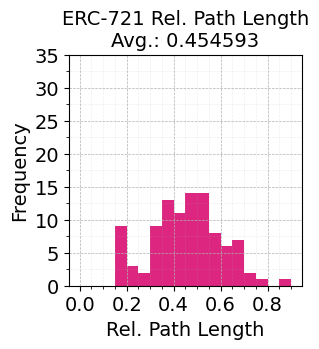

In [7]:
data = final['est_apl']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Rel. Path Length\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Rel. Path Length')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0, 95, 5) / 100, color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 35)
set_font_size(ax, 14)
plt.savefig("figures/nft_feature_apl_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

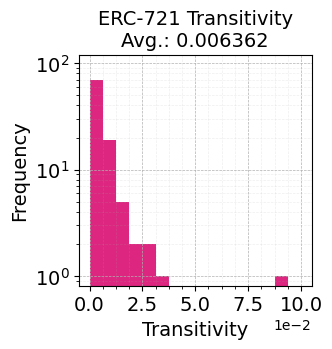

In [8]:
data = final['transitivity']
hist_bins = np.arange(0, 0.1 + 0.00625, step=0.00625)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Transitivity\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Transitivity')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.hist(data, bins=hist_bins, color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,-2))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.set_ylim(top=120)
set_font_size(ax, 14)
plt.savefig("figures/nft_feature_transitivity_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

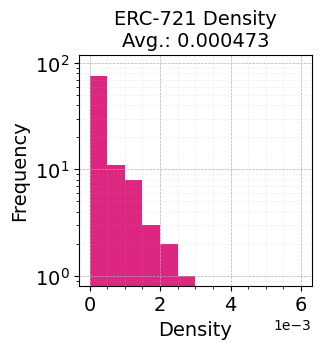

In [9]:
data = final['density']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Density\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Density')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.hist(data, bins=np.arange(0, 0.006 + 0.0005, step=0.0005), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3,-3))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.set_ylim(top=120)
set_font_size(ax, 14)
plt.savefig("figures/nft_feature_density_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Clustering

In this section we analyze the results of our clustering analysis.

### K-Means

We start by importing the CSV file including all configurations tested with the K-Means algorithm.
This file has one row for each configuration and each configuration is described by the following attributes.

1. List of features used for the clustering.
2. Number of clusters $k$.
3. Silhouette score of the clustering.
4. Homogeneity score of the clustering (computed w.r.t. the manual labeling describing the contract semantics).

In [11]:
kmeans_results = pd.read_csv('results/nft/nft_kmeans.csv')
kmeans_results

,features,k,silhouette,homogeneity
0,coverage,2,0.746909,0.014691
1,coverage,3,0.733027,0.033858
2,coverage,4,0.693253,0.052207
3,coverage,5,0.662845,0.077832
4,coverage,6,0.664838,0.106051
...,...,...,...,...
584,coverage diameter est_apl transitivity density,16,0.318583,0.557304
585,coverage diameter est_apl transitivity density,17,0.321567,0.546840
586,coverage diameter est_apl transitivity density,18,0.323332,0.612761
587,coverage diameter est_apl transitivity density,19,0.326946,0.636610


We now proceed as follows.

1. We select the best configuration for each feature subset, in accordance with the silhouette score.
2. We select the top 3 configurations yielding the highest silhouette score.
3. We visualize (with a bar plot) the compositions of clusters in these 3 configurations.

In [12]:
x = kmeans_results.sort_values("silhouette", ascending=False).groupby("features", as_index=False).first()
x.sort_values("silhouette", ascending=False).head(3)

,features,k,silhouette,homogeneity
0,coverage,2,0.746909,0.014691
29,transitivity,20,0.665380,0.453699
17,diameter,3,0.659975,0.187302


For the last step, we define the following function in order to build the plots.

In [26]:
def plot_clustering(features, k, filename = None):
    features_str = ' '.join(features)
    clust_data = PowerTransformer().fit_transform(final[features])
    #clust_data = StandardScaler().fit_transform(final[features])
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
    pred_labels = kmeans.fit_predict(clust_data)
    sil = silhouette_score(clust_data, pred_labels)
    result = pd.DataFrame(clust_data).assign(label = pred_labels)
    plt.figure(figsize=(3, 3))
    plt.title(f'Features: [{features_str}]\nSilhouette: {round(sil, 6)}')
    sns.countplot(x='label', color='#dc267f', data=result)
    plt.xlabel('Cluster ID')
    plt.ylabel('N. of contracts')
    #plt.grid(axis='y', linestyle='--', linewidth=0.5)
    plt.grid(which='major', linestyle='--', linewidth=0.5)
    plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    plt.minorticks_on()
    plt.ylim(top=105)
    set_font_size(plt.gca(), 14)
    if (not (filename is None)):
        plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()

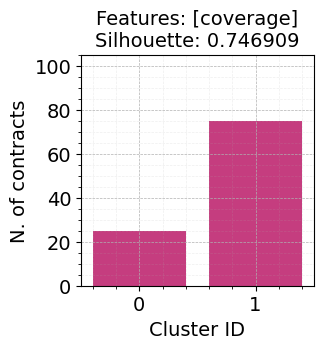

In [27]:
plot_clustering(['coverage'], 2, 'figures/nft_kmeans_top_1.pdf')

### PCA

We conduct further analysis based on dimensionality reduction. In particular:

1. We use principal component analysis to reduce the number of features.
2. We execute the K-means algorithm on this reduced data set.

Before applying the dimensionality reduction we use the _explained variance ratio_ method to determine the optimal number of components.

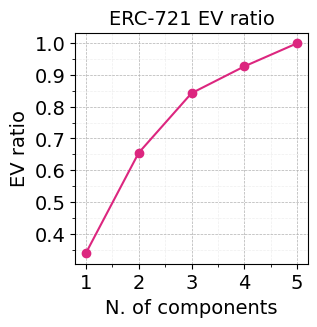

In [7]:
final = pd.read_csv('results/nft/nft_final.csv')
features = ['coverage', 'diameter', 'est_apl', 'transitivity', 'density']
data = StandardScaler().fit_transform(final[features])
pca = PCA()
pca.fit(data)

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 EV ratio')
ax.set_xlabel('N. of components')
ax.set_ylabel('EV ratio')
ax.plot(range(1, 6), pca.explained_variance_ratio_.cumsum(), marker='o', color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)

plt.savefig('figures/nft_pca_explained_variance.pdf', format='pdf', bbox_inches='tight')
plt.show()

We select $n=3$ as the optimal number of components (preserving at least 80\% of the orginal variance) and then execute K-means for different values of $k$ (i.e., ranging from 2 to 20, included). Below, we print the silhouette scores obtained for different values of $k$.

In [8]:
data = StandardScaler().fit_transform(final[features])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmin = 2
kmax = 20
sil = []
for k in np.arange(kmin, kmax+1):
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
    pred_labels = kmeans.fit_predict(X)
    sil.append(silhouette_score(X, pred_labels))
result = pd.DataFrame({'k' : np.arange(kmin, kmax+1), 'silhouette' : sil})
result

,k,silhouette
0,2,0.576905
1,3,0.498529
2,4,0.529623
3,5,0.446625
4,6,0.417971
5,7,0.408486
6,8,0.381352
7,9,0.387984
8,10,0.372150
9,11,0.379251


Then we plot the silhouette scores obtained for different values of $k$.

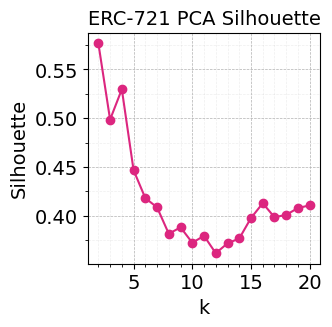

In [9]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 PCA Silhouette')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette')
ax.plot(result.k, result.silhouette, marker='o', color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)

plt.savefig('figures/nft_pca_silhouette.pdf', format='pdf', bbox_inches='tight')
plt.show()

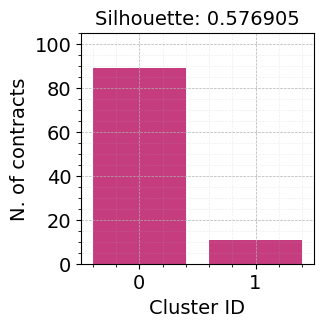

In [10]:
data = StandardScaler().fit_transform(final[features])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=2, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(X)
sil = silhouette_score(X, pred_labels)
result = pd.DataFrame(X).assign(label = pred_labels)#.assign(category = final.category)
plt.figure(figsize=(3, 3))
plt.title(f'Silhouette: {round(sil, 6)}')
sns.countplot(x='label', color='#dc267f', data=result)
plt.xlabel('Cluster ID')
plt.ylabel('N. of contracts')
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.minorticks_on()
plt.ylim(top=105)
set_font_size(plt.gca(), 14)
plt.savefig('figures/nft_pca_clustering.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Categorization

We manually assign to each contract (i.e., each network) a categorical label describing its main application domain.

1. defi comprises all tokens related to decentralized finance (e.g., stablecoins, wrapped tokens, tokens issued by exchanges and automated market makers, etc.);
2. games includes all token related to games; 
3. blockchain denotes all tokens related to independent blockchain projects; 
4. layer-2 contains tokens related to layer-2 solutions aimed at improving the scalability of Ethereum; 
5. content includes reward tokens related to content creation platforms; 
6. storage represents all tokens related to decentralized storage solutions; 
7. mining indicates tokens associated with cryptocurrency mining services; 
8. multimedia comprises all tokens related to multimedia content (e.g., music, video streaming services, etc.); 
9. other comprises all tokens whose ap- plication domain is not included into any of the previous categories.

In [13]:
final = pd.read_csv('results/nft/nft_final.csv')
final

,contract_id,label,possible_spam,category,category_id,comp_nodes,coverage,alpha,error,diameter,est_apl,transitivity,density
0,0,Ethereum Name Service,False,domain-names,4,475139,0.999952,2.455325,0.012106,11.934486,0.189888,0.000003,0.000005
1,1,Gods Unchained Cards,False,gaming,1,6841,0.967746,1.948671,0.024060,1.245656,0.354859,0.009671,0.001005
2,2,Sorare,False,gaming,1,29821,0.999430,2.074105,0.043536,0.970594,0.244640,0.010292,0.000680
3,3,Art Blocks,False,art,2,52451,0.953949,3.232256,0.028880,1.472261,0.411514,0.018652,0.000124
4,4,Foundation,False,art,2,47934,0.998271,3.090472,0.013191,2.783556,0.197647,0.000015,0.000046
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,The Heart Project,False,pfps,0,18458,0.968365,2.667838,0.012044,2.748580,0.638165,0.003304,0.000165
96,96,3Landers,False,pfps,0,16950,0.974194,2.848802,0.022792,2.156495,0.657548,0.003704,0.000186
97,97,Groupies,False,pfps,0,10963,0.998634,3.036929,0.024330,1.720008,0.481739,0.001951,0.000407
98,98,Pablos,False,pfps,0,13039,0.995800,2.631901,0.023805,1.582996,0.463189,0.002063,0.000277


In [46]:
final[(final.category == 'other') & (final.possible_spam == True)]

,contract_id,label,possible_spam,category,category_id,comp_nodes,coverage,alpha,error,diameter,est_apl,transitivity,density
7,7,DusktopiaNFT,True,other,5,57796,1.000000,11.766418,0.000255,0.273606,0.182399,0.000000,0.000035
11,11,Dusk Topia,True,other,5,39296,1.000000,11.262918,0.000360,0.283584,0.189050,0.000000,0.000051
15,15,Ecotars,True,other,5,35250,1.000000,11.121587,0.000397,0.286527,0.191011,0.000000,0.000057
19,19,Great Goats,True,other,5,42835,1.000000,11.166001,0.000347,0.375055,0.187528,0.000000,0.000047
20,20,FaceX,True,other,5,42114,0.999953,11.302927,0.000043,0.281739,0.187823,0.000000,0.000047
26,26,Great Goats NFT,True,other,5,24946,0.999920,10.673372,0.000540,0.296312,0.197531,0.000000,0.000080
30,30,Primates,True,other,5,27661,0.999928,10.545914,0.000534,0.391092,0.195547,0.000000,0.000072
31,31,Oak Paradise NFT,True,other,5,16167,0.999876,10.212806,0.000062,0.206383,0.206360,0.000000,0.000124
40,40,goblintown,True,other,5,20760,0.982861,2.621738,0.017732,1.408340,0.484922,0.004446,0.000176
62,62,DusktopiaNFT,True,other,5,18737,1.000000,10.304241,0.000696,0.304932,0.203275,0.000000,0.000107


In [17]:
final.category.value_counts()

category
pfps              48
gaming            18
art               14
other             13
virtual-worlds     5
domain-names       2
Name: count, dtype: int64

Now, let us consider all K-means configurations obtained for $k=5$. Among them we select:

1. The one yielding the maximum silhouette score.
2. The one yielding the maximum homogeneity score.

In [14]:
kmeans_results = pd.read_csv('results/nft/nft_kmeans.csv')
kmeans_results_5 = kmeans_results[kmeans_results.k == 5]
max_sil = kmeans_results_5[kmeans_results_5.silhouette == np.max(kmeans_results_5.silhouette)]
max_hom = kmeans_results_5[kmeans_results_5.homogeneity == np.max(kmeans_results_5.homogeneity)]

In [15]:
max_sil

,features,k,silhouette,homogeneity
3,coverage,5,0.662845,0.077832


In [16]:
max_hom

,features,k,silhouette,homogeneity
364,coverage est_apl density,5,0.464929,0.375396


In [18]:
colors = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
cmap = LinearSegmentedColormap.from_list('my_cmap', colors)
categories = final.category_id.values

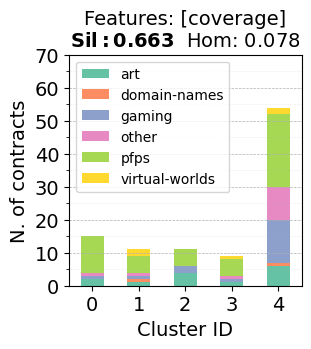

In [19]:
features = ['coverage']
k = 5
features_str = ' '.join(features)
clust_data = PowerTransformer().fit_transform(final[features])
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(clust_data)
sil = silhouette_score(clust_data, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pd.DataFrame(clust_data).assign(label = pred_labels).assign(category = final.category.values)
xt = pd.crosstab(result.label, result.category)

fig, ax = plt.subplots(figsize=(3, 3))
xt.plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(f'Features: [{features_str}]\n' + r'$\bf{Sil: {' + str(round(sil, 3)) + r'}}$' + f'  Hom: {round(hom, 3)}')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(top=70)
ax.legend(loc='upper left')
set_font_size(ax, 14)
plt.savefig('figures/nft_hom_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

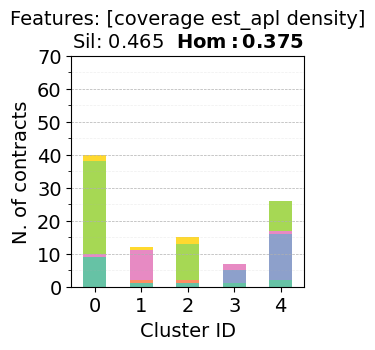

In [21]:
features = ['coverage', 'est_apl', 'density']
k = 5
features_str = ' '.join(features)
clust_data = PowerTransformer().fit_transform(final[features])
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(clust_data)
sil = silhouette_score(clust_data, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pd.DataFrame(clust_data).assign(label = pred_labels).assign(category = final.category.values)
xt = pd.crosstab(result.label, result.category)

fig, ax = plt.subplots(figsize=(3, 3))
xt.plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
title = f'Features: [coverage est_apl density]\n' + \
    'Sil: {:.3f}  '.format(sil) + r'$\bf{Hom: {' + str(round(hom,3)) + r'}}$'
ax.set_title(title)
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(top=70)
set_font_size(ax, 14)
plt.savefig('figures/nft_hom_2.pdf', format='pdf', bbox_inches='tight')
plt.show()

Finally, we also plot the cluster subdivision for the configuration obtained with $k=5$ on the PCA-reduced data set.

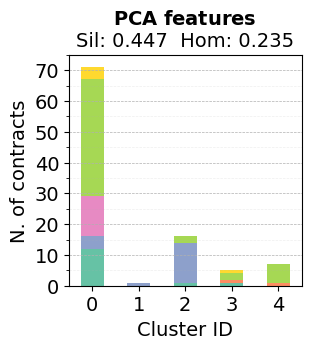

In [47]:
features = ['coverage', 'diameter', 'est_apl', 'transitivity', 'density']
k = 5
data = StandardScaler().fit_transform(final[features])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=5, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(X)
sil = silhouette_score(X, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pd.DataFrame(data).assign(label = pred_labels).assign(category = final.category.values)
xt = pd.crosstab(result.label, result.category)

fig, ax = plt.subplots(figsize=(3, 3))
xt.plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(r"$\bf{PCA\ features}$" + f"\nSil: {round(sil, 3)}  Hom: {round(hom, 3)}")
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(top=75)
set_font_size(ax, 14)
plt.savefig('figures/nft_hom_3.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [50]:
groups = result.groupby('label').groups
spam_ids = final[final.possible_spam == True].contract_id.values
for x in groups:
    print(np.intersect1d(spam_ids, groups[x]))

[ 7 11 15 19 20 22 26 30 31 40 62 87]
[]
[]
[54]
[]


## Temporal analysis by category

In [2]:
block_timestamps = pd.read_csv('data/block_timestamps_0-14999999.csv', header=None, names=['blockId', 'timestamp'])
block_timestamps

,blockId,timestamp
0,0,1438269973
1,1,1438269988
2,2,1438270017
3,3,1438270048
4,4,1438270077
...,...,...
14999995,14999995,1655778452
14999996,14999996,1655778455
14999997,14999997,1655778471
14999998,14999998,1655778488


In [3]:
event_count = pd.read_csv('results/nft/nft_category_count.csv').rename(columns={'blockId_category':'blockId'})
event_count = event_count.set_index('blockId').reindex(np.arange(0, 15000000), fill_value=0).reset_index()
event_count = event_count.merge(block_timestamps, on='blockId', how='left')
event_count

,blockId,art,domain-names,gaming,other,pfps,virtual-worlds,timestamp
0,0,0,0,0,0,0,0,1438269973
1,1,0,0,0,0,0,0,1438269988
2,2,0,0,0,0,0,0,1438270017
3,3,0,0,0,0,0,0,1438270048
4,4,0,0,0,0,0,0,1438270077
...,...,...,...,...,...,...,...,...
14999995,14999995,0,0,0,0,0,0,1655778452
14999996,14999996,0,3,0,0,1,0,1655778455
14999997,14999997,0,1,1,0,0,0,1655778471
14999998,14999998,0,0,0,0,0,0,1655778488


In [4]:
categories = np.setdiff1d(event_count.columns.values, ['blockId', 'timestamp'])
seconds_in_a_week = 60 * 60 * 24 * 7
start_date = np.int64(pd.Timestamp(2015, 1, 1).timestamp())
end_date = np.int64(pd.Timestamp(2023, 1, 1).timestamp())
hist_bins = np.arange(start_date, end_date + seconds_in_a_week, seconds_in_a_week)
timestamps = pd.to_datetime(event_count.timestamp).astype(np.int64).values

df_data = dict()
for cat in categories:
    bs = stats.binned_statistic(timestamps, event_count[cat].values, statistic='sum', bins=hist_bins)
    df_data[cat] = bs.statistic
df_data['timestamp'] = bs.bin_edges[:-1]

event_count_ext = pd.DataFrame(df_data).astype(int)
event_count_ext['sum'] = np.sum(event_count_ext[categories], axis=1)
for cat in categories:
    event_count_ext[cat + 'Perc'] = event_count_ext[cat] / event_count_ext['sum']
event_count_ext = event_count_ext.fillna(0)
event_count_ext

,art,domain-names,gaming,other,pfps,virtual-worlds,timestamp,sum,artPerc,domain-namesPerc,gamingPerc,otherPerc,pfpsPerc,virtual-worldsPerc
0,0,0,0,0,0,0,1420070400,0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,1420675200,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,1421280000,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,1421884800,0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,1422489600,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0,0,0,0,0,0,1669852800,0,0.0,0.0,0.0,0.0,0.0,0.0
414,0,0,0,0,0,0,1670457600,0,0.0,0.0,0.0,0.0,0.0,0.0
415,0,0,0,0,0,0,1671062400,0,0.0,0.0,0.0,0.0,0.0,0.0
416,0,0,0,0,0,0,1671667200,0,0.0,0.0,0.0,0.0,0.0,0.0


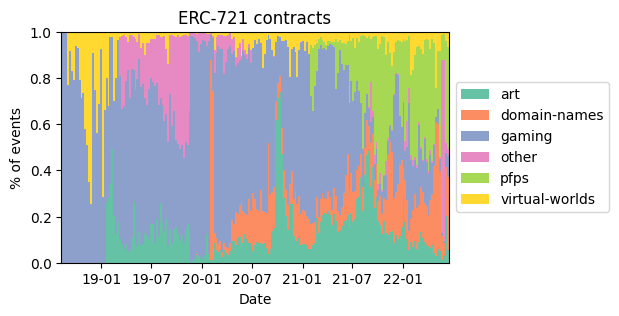

In [5]:
x = event_count_ext[event_count_ext['sum'] > 0]
dates = x.timestamp.astype(dtype='datetime64[s]')

fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-721 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('% of events')
ax1.stackplot(dates, x['artPerc'], x['domain-namesPerc'], x['gamingPerc'], x['otherPerc'], x['pfpsPerc'], x['virtual-worldsPerc'],
             colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f'],
             labels=['art', 'domain-names', 'gaming', 'other', 'pfps', 'virtual-worlds'], 
             step='post')
ax1.margins(0,0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

plt.savefig("figures/nft_events_category.pdf", format='pdf', bbox_inches='tight')
plt.show()

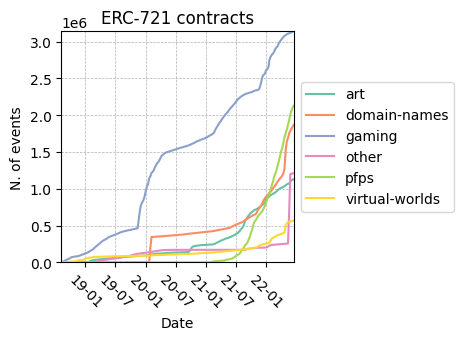

In [21]:
x = event_count_ext[event_count_ext['sum'] > 0]
dates = x.timestamp.astype(dtype='datetime64[s]')
colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
labels=['art', 'domain-names', 'gaming', 'other', 'pfps', 'virtual-worlds']

fig = plt.figure(figsize=(3, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-721 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('N. of events')
for i in range(0, len(labels)):
    ax1.plot(dates, np.cumsum(x[labels[i]]), color=colors[i], label=labels[i])
ax1.margins(0,0)
ax1.grid(which='major', linestyle='--', linewidth=0.5)
#ax1.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax1.tick_params(axis='x', labelrotation=-45)

plt.savefig("figures/nft_events_category_cumulative.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Top 3 contracts

In [40]:
contract_count = pd.read_csv('results/nft/nft_top_count.csv').rename(columns={'blockId_contractId':'blockId'})
contract_count = contract_count.set_index('blockId').reindex(np.arange(0, 15000000), fill_value=0).reset_index()
contract_count['timestamp'] = block_timestamps['timestamp']
contract_count

,blockId,10178,10976,11222,11558,11858,11948,11966,12510,12611,...,75125,75633,75878,78048,784,8611,8895,9817,9962,timestamp
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438269973
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438269988
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438270017
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438270048
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438270077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999995,14999995,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1655778452
14999996,14999996,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1655778455
14999997,14999997,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1655778471
14999998,14999998,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1655778488


In [41]:
contract_ids = np.setdiff1d(contract_count.columns.values, ['blockId', 'timestamp'])
seconds_in_a_week = 60 * 60 * 24 * 7
start_date = np.int64(pd.Timestamp(2015, 1, 1).timestamp())
end_date = np.int64(pd.Timestamp(2023, 1, 1).timestamp())
hist_bins = np.arange(start_date, end_date + seconds_in_a_week, seconds_in_a_week)
timestamps = pd.to_datetime(contract_count.timestamp).astype(np.int64).values

df_data = dict()
bs = None
for i in contract_ids:
    bs = stats.binned_statistic(timestamps, contract_count[i].values, statistic='sum', bins=hist_bins)
    df_data[i] = bs.statistic
df_data['timestamp'] = bs.bin_edges[:-1]

contract_count_ext = pd.DataFrame(df_data).astype(int)
total = np.sum(contract_count_ext[contract_ids], axis=1)
top_1 = np.max(contract_count_ext[contract_ids], axis=1)
top_2 = pd.Series(np.partition(contract_count_ext[contract_ids], -2, axis=1)[:, -2])
top_3 = pd.Series(np.partition(contract_count_ext[contract_ids], -3, axis=1)[:, -3])
others = total - (top_1 + top_2 + top_3)
ft = pd.DataFrame({'timestamp' : contract_count_ext.timestamp, 'top1' : top_1, 'top2' : top_2, 'top3' : top_3, 'remaining' : others, 'total' : total})
ft['top1Perc'] = ft['top1']/ft['total']
ft['top2Perc'] = ft['top2']/ft['total']
ft['top3Perc'] = ft['top3']/ft['total']
ft['remainingPerc'] = ft['remaining']/ft['total']
ft = ft.fillna(0)
ft

,timestamp,top1,top2,top3,remaining,total,top1Perc,top2Perc,top3Perc,remainingPerc
0,1420070400,0,0,0,0,0,0.0,0.0,0.0,0.0
1,1420675200,0,0,0,0,0,0.0,0.0,0.0,0.0
2,1421280000,0,0,0,0,0,0.0,0.0,0.0,0.0
3,1421884800,0,0,0,0,0,0.0,0.0,0.0,0.0
4,1422489600,0,0,0,0,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
413,1669852800,0,0,0,0,0,0.0,0.0,0.0,0.0
414,1670457600,0,0,0,0,0,0.0,0.0,0.0,0.0
415,1671062400,0,0,0,0,0,0.0,0.0,0.0,0.0
416,1671667200,0,0,0,0,0,0.0,0.0,0.0,0.0


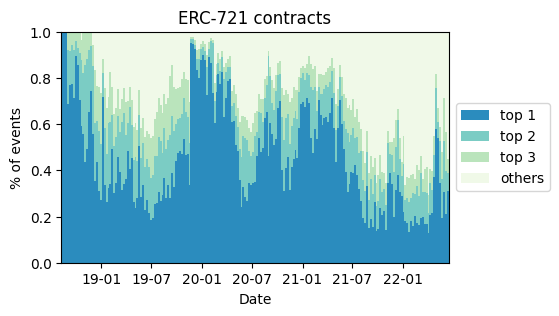

In [46]:
x = ft[ft.total > 0]
dates = x.timestamp.astype(dtype='datetime64[s]')

fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-721 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('% of events')
ax1.stackplot(dates, x['top1Perc'], x['top2Perc'], x['top3Perc'], x['remainingPerc'],
            colors=['#2b8cbe', '#7bccc4', '#bae4bc', '#f0f9e8'],
            labels=['top 1', 'top 2', 'top 3', 'others'], 
            step='post')
ax1.margins(0,0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

plt.savefig("figures/nft_events_top.pdf", format='pdf', bbox_inches='tight')
plt.show()